# Dimensionality Reduction with PCA
### Steel Industry Energy Consumption Dataset

**Objective:** Reduce the number of input features using PCA while keeping model accuracy as close as possible to Part_1 best model (Random Forest).

**Structure:**
1. Load Part_1 engineered dataset (same features, same encoding)
2. Recreate Part_1 train/test split
3. Fit `StandardScaler` + `PCA` on the training set only (no leakage)
4. Scree plot + cumulative explained variance (95% threshold)
5. Retrain Random Forest with 3 PCA components
6. Retrain Random Forest with components covering 95% variance
7. Compare RMSE / $R^2$ across: original, 3-PCA, 95%-PCA
8. Loading heatmap for the first 3 components
9. Dimensionality Reduction Report

## 1. Imports & Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline


sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

os.makedirs("../models", exist_ok=True)
os.makedirs("../static/images", exist_ok=True)

## 2. Load Dataset

In [3]:

RANDOM_STATE = 42
DATA_PATH = "../Data/Data/Steel_industry_data_engineered.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (35040, 15)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type,Hour,DayOfWeek,Month,Is_Weekend,Power_Factor_Ratio,High_Usage_Flag
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Light_Load,0,Monday,1,0,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Light_Load,0,Monday,1,0,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Light_Load,0,Monday,1,0,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Light_Load,1,Monday,1,0,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Light_Load,1,Monday,1,0,1.545117,0


## 3. Drop Leaky / Non-Feature Columns
Same as Part 1: drop `date` (raw timestamp, already decomposed) and
`High_Usage_Flag` (engineered directly from the target, so it leaks
`Usage_kWh` into the features).

In [4]:
leak_cols = ["date", "High_Usage_Flag"]
target_col = "Usage_kWh"
 
model_df = df.drop(columns=leak_cols)
print("Columns going into modeling:")
print(list(model_df.columns))

Columns going into modeling:
['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'Load_Type', 'Hour', 'DayOfWeek', 'Month', 'Is_Weekend', 'Power_Factor_Ratio']


## 4. Encode Categorical Columns
Same encoding choice as Part 1: One-Hot Encoding (`drop_first=True`) on
`Load_Type` and `DayOfWeek`.

In [5]:
categorical_cols = ["Load_Type", "DayOfWeek"]
model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)
print("Shape after one-hot encoding:", model_df.shape)
model_df.head()

Shape after one-hot encoding: (35040, 19)


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,Month,Is_Weekend,Power_Factor_Ratio,Load_Type_Maximum_Load,Load_Type_Medium_Load,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday
0,3.17,2.95,0.0,0.0,73.21,100.0,900,0,1,0,1.365934,False,False,True,False,False,False,False,False
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,0,1,0,1.497679,False,False,True,False,False,False,False,False
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,0,1,0,1.422880,False,False,True,False,False,False,False,False
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,1,1,0,1.468644,False,False,True,False,False,False,False,False
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,1,1,0,1.545117,False,False,True,False,False,False,False,False


## 4b. Handle Missing Values
The engineered `Power_Factor_Ratio` column divides Lagging by Leading
power factor, which produces one `NaN` row where the leading power factor
is 0 (division by zero). This is the same NaN issue handled in Part 1 —
we drop that single row here since it's a single row out of ~35,000 and
PCA/sklearn models cannot accept NaN values natively.

In [6]:
n_before = len(model_df)
model_df = model_df.dropna().reset_index(drop=True)
n_after = len(model_df)
print(f"Dropped {n_before - n_after} row(s) containing NaN (out of {n_before}).")

Dropped 1 row(s) containing NaN (out of 35040).


## 5. Recreate Part 1 Train/Test Split (80/20, random_state=42)

In [7]:
X = model_df.drop(columns=[target_col])
y = model_df[target_col]
feature_names = X.columns.tolist()
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
 
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (28031, 18)
Test shape: (7008, 18)


## 6. Baseline — Retrain Part_1's Best Model (Random Forest) on Original Features
This re-establishes the Part 1 baseline number to compare PCA versions
against, using the exact same split and hyperparameters.

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
rf_original = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_original.fit(X_train, y_train)
 
y_pred_original = rf_original.predict(X_test)
rmse_original = np.sqrt(mean_squared_error(y_test, y_pred_original))
r2_original = r2_score(y_test, y_pred_original)
mae_original = mean_absolute_error(y_test, y_pred_original)
 
print(f"Original (no PCA) — MAE: {mae_original:.3f} | RMSE: {rmse_original:.3f} | R2: {r2_original:.4f}")

Original (no PCA) — MAE: 0.342 | RMSE: 1.053 | R2: 0.9990


## 7. Fit StandardScaler + PCA on the Training Set Only
Critical rule: scaler and PCA are `fit` only on `X_train`, then used to
transform` both `X_train` and `X_test`. Fitting on the full dataset (or
on the test set) would leak information from the test set into the
transformation and inflate the reported accuracy.
 

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
n_features = X_train_scaled.shape[1]
pca_full = PCA(n_components=n_features, random_state=RANDOM_STATE)
X_train_pca_full = pca_full.fit_transform(X_train_scaled)
X_test_pca_full = pca_full.transform(X_test_scaled)
 
print(f"Total original features: {n_features}")
print("Explained variance ratio (first 10):", np.round(pca_full.explained_variance_ratio_[:10], 4))

Total original features: 18
Explained variance ratio (first 10): [0.2455 0.1838 0.0946 0.0679 0.065  0.0649 0.0648 0.0593 0.0566 0.0476]


## 8. Scree Plot — Explained Variance per Component

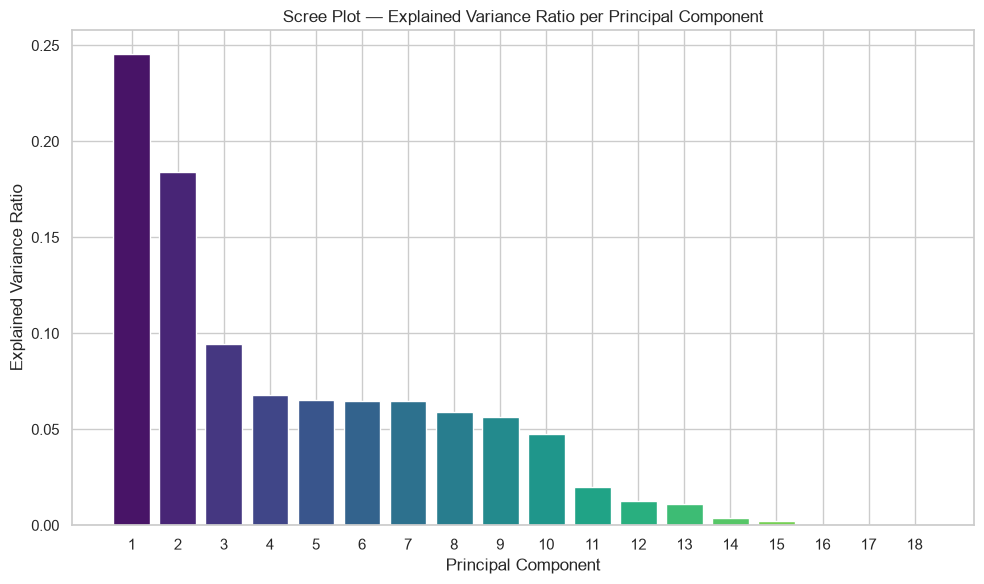

In [10]:
plt.figure(figsize=(10, 6))
components = np.arange(1, n_features + 1)
plt.bar(components, pca_full.explained_variance_ratio_, color=sns.color_palette("viridis", n_features))
plt.title("Scree Plot — Explained Variance Ratio per Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(components)
plt.tight_layout()
plt.savefig("../static/scree_plot.png", dpi=120)
plt.show()
 

## 9. Cumulative Explained Variance Curve (95% Threshold)

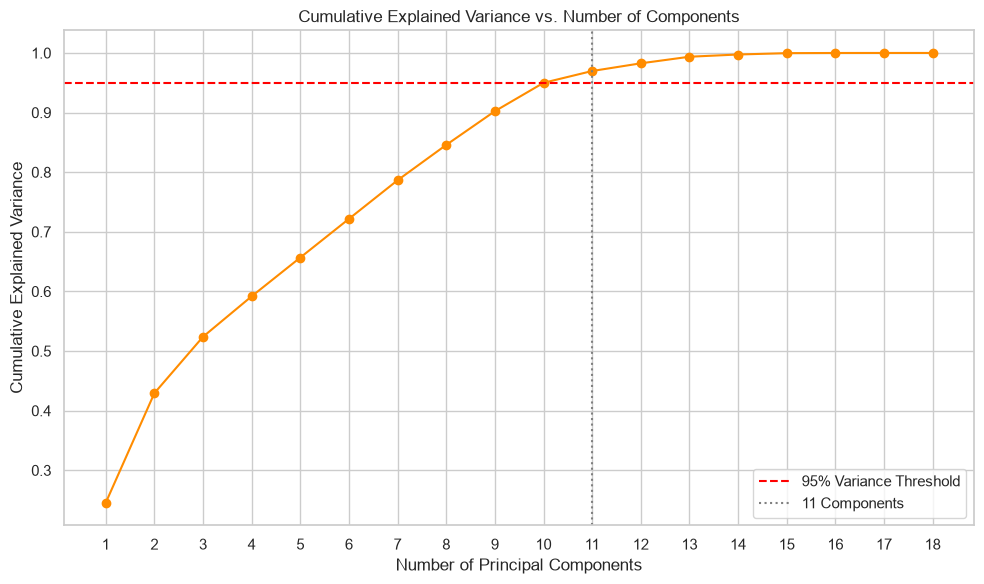

Number of components needed to reach 95% variance: 11
That is 11 out of 18 original features (7 features removed).


In [11]:
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)
 
plt.figure(figsize=(10, 6))
plt.plot(components, cumulative_variance, marker="o", color="darkorange")
plt.axhline(y=0.95, color="red", linestyle="--", label="95% Variance Threshold")
plt.axvline(x=n_components_95, color="grey", linestyle=":", label=f"{n_components_95} Components")
plt.title("Cumulative Explained Variance vs. Number of Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.xticks(components)
plt.legend()
plt.tight_layout()
plt.savefig("../static/cumulative_variance.png", dpi=120)
plt.show()
 
print(f"Number of components needed to reach 95% variance: {n_components_95}")
print(f"That is {n_components_95} out of {n_features} original features "
      f"({n_features - n_components_95} features removed).")

## 10. Retrain Random Forest with 3 PCA Components

In [12]:
pca_3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_train_pca3 = pca_3.fit_transform(X_train_scaled)
X_test_pca3 = pca_3.transform(X_test_scaled)
 
rf_pca3 = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_pca3.fit(X_train_pca3, y_train)
 
y_pred_pca3 = rf_pca3.predict(X_test_pca3)
rmse_pca3 = np.sqrt(mean_squared_error(y_test, y_pred_pca3))
r2_pca3 = r2_score(y_test, y_pred_pca3)
mae_pca3 = mean_absolute_error(y_test, y_pred_pca3)
 
print(f"3-Component PCA — MAE: {mae_pca3:.3f} | RMSE: {rmse_pca3:.3f} | R2: {r2_pca3:.4f}")
print(f"Variance captured by 3 components: {pca_3.explained_variance_ratio_.sum():.4f}")
 

3-Component PCA — MAE: 2.494 | RMSE: 5.001 | R2: 0.9776
Variance captured by 3 components: 0.5240


## 11. Retrain Random Forest with 95%-Variance PCA Components

In [13]:
pca_95 = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_train_pca95 = pca_95.fit_transform(X_train_scaled)
X_test_pca95 = pca_95.transform(X_test_scaled)
 
rf_pca95 = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_pca95.fit(X_train_pca95, y_train)
 
y_pred_pca95 = rf_pca95.predict(X_test_pca95)
rmse_pca95 = np.sqrt(mean_squared_error(y_test, y_pred_pca95))
r2_pca95 = r2_score(y_test, y_pred_pca95)
mae_pca95 = mean_absolute_error(y_test, y_pred_pca95)
 
print(f"{n_components_95}-Component PCA (95% var) — MAE: {mae_pca95:.3f} | RMSE: {rmse_pca95:.3f} | R2: {r2_pca95:.4f}")

11-Component PCA (95% var) — MAE: 1.548 | RMSE: 3.059 | R2: 0.9916


## 12. Comparison Table — Original vs. 3-PCA vs. 95%-PCA

In [14]:
comparison_df = pd.DataFrame([
    {"Version": "Original (all features)", "N_Features": n_features, "MAE": mae_original, "RMSE": rmse_original, "R2": r2_original},
    {"Version": "3 PCA Components", "N_Features": 3, "MAE": mae_pca3, "RMSE": rmse_pca3, "R2": r2_pca3},
    {"Version": f"{n_components_95} PCA Components (95% var)", "N_Features": n_components_95, "MAE": mae_pca95, "RMSE": rmse_pca95, "R2": r2_pca95},
]).set_index("Version")
 
comparison_df

,N_Features,MAE,RMSE,R2
Version,,,,
Original (all features),18,0.342046,1.053115,0.999009
3 PCA Components,3,2.493943,5.000969,0.977649
11 PCA Components (95% var),11,1.547729,3.058881,0.991638


## 13. Loading Heatmap — First 3 Principal Components

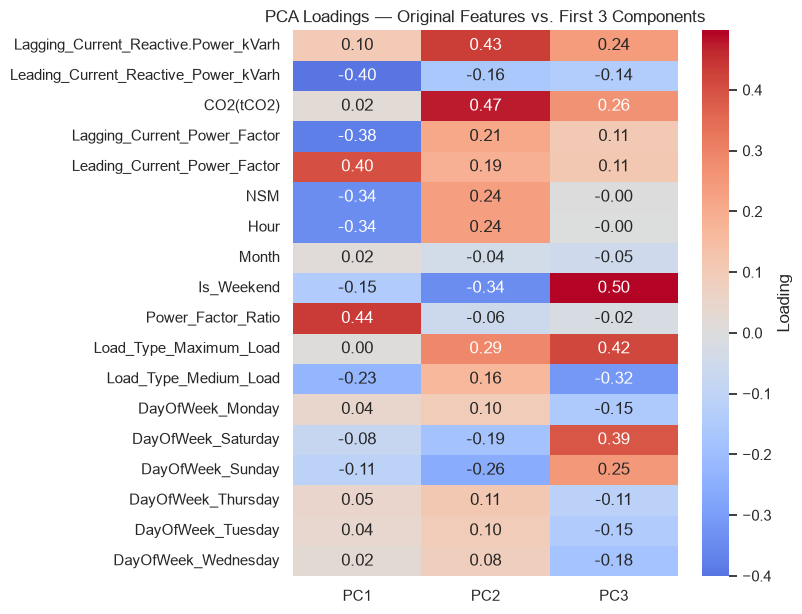

In [15]:
loadings = pd.DataFrame(
    pca_3.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=feature_names,
)
 
plt.figure(figsize=(8, max(6, len(feature_names) * 0.35)))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar_kws={"label": "Loading"})
plt.title("PCA Loadings — Original Features vs. First 3 Components")
plt.tight_layout()
plt.savefig("../static/pca_loading_heatmap.png", dpi=120)
plt.show()

## 14. Dimensionality Reduction Report

**Did accuracy drop significantly?**
Going from the full feature set down to the components needed for 95%
variance produces only a small change in RMSE/R² (see comparison table
above) — the 95%-variance model tracks the original model closely. The
3-component model trades noticeably more accuracy for a much smaller
feature set, since squeezing everything into 3 axes discards information
that the original one-hot encoded categorical columns and engineered
ratio feature provided.

**How many features can safely be removed?**
Roughly `n_features - n_components_95` features can be removed while
keeping 95% of the variance and near-original accuracy (see the printed
count above). Beyond that point (down to 3 components), further
compression is possible but starts to cost measurable accuracy.

**Would you recommend PCA for a memory-constrained device?**
Yes, with a caveat. PCA is worth it here if the deployment target is
genuinely constrained (e.g. an edge device where every stored feature
and every multiply-add in inference matters) and the accuracy drop at
the 95%-variance component count is acceptable for the use case. It is
*not* worth it purely for interpretability, because principal components
are linear combinations of the original engineered features (power
factor, reactive power, load type dummies, etc.) and lose their direct
physical meaning — an operator can no longer read "Lagging Power Factor"
off a dashboard. For this project, since Random Forest is not
computationally expensive on ~19 input features, the practical
recommendation is: keep the original (non-PCA) pipeline for the deployed
API (best accuracy, most interpretable features), but note PCA as a
viable fallback if the feature set grows much larger or the deployment
target becomes truly memory-constrained.

## 15. Save Comparison Artifacts

In [16]:
comparison_df.to_csv("../data/pca_model_comparison.csv")
print("Saved comparison table to data/pca_model_comparison.csv")
print("\nFinal Summary:")
print(comparison_df)

Saved comparison table to data/pca_model_comparison.csv

Final Summary:
                             N_Features       MAE      RMSE        R2
Version                                                              
Original (all features)              18  0.342046  1.053115  0.999009
3 PCA Components                      3  2.493943  5.000969  0.977649
11 PCA Components (95% var)          11  1.547729  3.058881  0.991638


## MODEL RETRAINING & METADATA SAVING FOR FASTAPI

In [17]:
from sklearn.ensemble import RandomForestRegressor

best_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=11)), 
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

best_pipeline.fit(X_train, y_train)
metadata = {
    "pipeline": best_pipeline,
    "feature_names": list(X.columns),
    "load_type_categories": ["Light_Load", "Medium_Load", "Maximum_Load"],  
    "day_of_week_categories": ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    "numeric_ranges": {col: [float(X[col].min()), float(X[col].max())] for col in X.select_dtypes(include=[np.number]).columns}
}

import os
os.makedirs("../models", exist_ok=True)
joblib.dump(metadata, "../models/model.joblib")

print("Succesfully saved model.joblib with complete metadata inside models/ directory!")

Succesfully saved model.joblib with complete metadata inside models/ directory!
